The missing values: 
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64
The Data Types: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1999 non-null   int64  
 1   week                   1999 non-null   int64  
 2   center_id              1999 non-null   int64  
 3   meal_id                1999 non-null   int64  
 4   checkout_price         1999 non-null   float64
 5   base_price             1999 non-null   float64
 6   emailer_for_promotion  1999 non-null   int64  
 7   homepage_featured      1999 non-null   int64  
 8   num_orders             1999 non-null   int64  
dtypes: float64(2), int64(7)

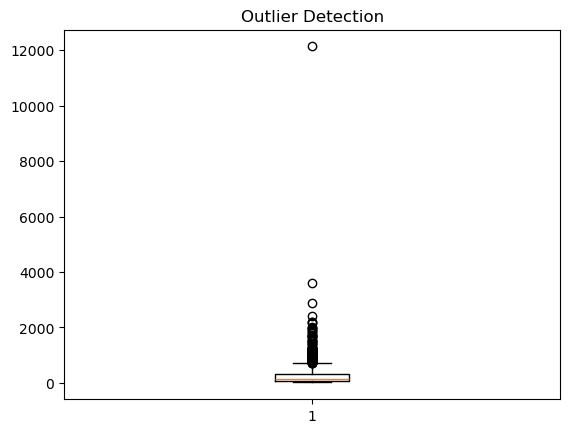

Check for noisy data: 


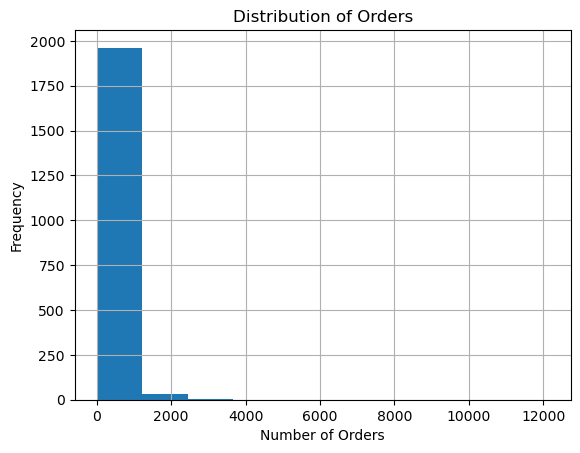

check for normalization: 


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,1.999000e+03,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,1.001093e+06,75.393197,81.649825,2010.123562,327.302596,347.972866,0.076538,0.105053,258.340170
std,6.323493e+02,41.743802,46.139173,554.686525,150.906902,158.625091,0.265924,0.306698,413.743045
min,1.000000e+06,1.000000,10.000000,1062.000000,65.020000,93.120000,0.000000,0.000000,13.000000
25%,1.000546e+06,40.000000,43.000000,1543.000000,222.645000,242.530000,0.000000,0.000000,55.000000
50%,1.001094e+06,78.000000,76.000000,1971.000000,292.030000,309.430000,0.000000,0.000000,148.000000
75%,1.001638e+06,111.500000,110.000000,2539.000000,435.530000,447.230000,0.000000,0.000000,324.000000
max,1.002181e+06,145.000000,186.000000,2956.000000,767.330000,767.330000,1.000000,1.000000,12137.000000


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv(r"D:\FDA_PBL_dataset\Food demand.csv")

print("The missing values: ")
print(df.isnull().sum())

print("The Data Types: ")
df.info()

plt.boxplot(df["num_orders"])
plt.title("Outlier Detection")
plt.show()

print("Check for noisy data: ")
df["num_orders"].hist()
plt.title("Distribution of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")
plt.show()

print("check for normalization: ")
df.describe()

In [7]:
df['Date'] = pd.to_datetime('2015-01-01') + pd.to_timedelta((df['week'] - 1) * 7, unit='D')
df['Day_of_Week'] = df['Date'].dt.day_name()
def get_meal_type(meal_id):
    if meal_id % 3 == 0:
        return 'Breakfast'
    elif meal_id % 3 == 1:
        return 'Lunch'
    else:
        return 'Dinner'

df['Meal_Type'] = df['meal_id'].apply(get_meal_type)
df['Consumed_Quantity'] = df['num_orders']
np.random.seed(50)

df['Prepared_Quantity'] = df['Consumed_Quantity'] + np.random.randint(5, 30, size=len(df))

df['Surplus'] = df['Prepared_Quantity'] - df['Consumed_Quantity']

df['Waste_%'] = (df['Surplus'] / df['Prepared_Quantity']) * 100

df_final = df[['Date','Day_of_Week','Meal_Type',
               'Prepared_Quantity','Consumed_Quantity',
               'Surplus','Waste_%']]

print(df_final.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               1999 non-null   datetime64[ns]
 1   Day_of_Week        1999 non-null   object        
 2   Meal_Type          1999 non-null   object        
 3   Prepared_Quantity  1999 non-null   int64         
 4   Consumed_Quantity  1999 non-null   int64         
 5   Surplus            1999 non-null   int64         
 6   Waste_%            1999 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 109.4+ KB
None


In [8]:
#replacing some values with NAN values
np.random.seed(50)

for col in ['Prepared_Quantity', 'Consumed_Quantity']:
    
    condition = df_final[col] < df_final[col].quantile(0.75)
    
    indices = df_final[condition].sample(frac=0.03).index
    
    df_final.loc[indices, col] = np.nan
    
indices = df_final.sample(frac=0.03).index
df_final.loc[indices, 'Meal_Type'] = np.nan

print(df_final.head())
print(df_final.isnull().sum())

        Date Day_of_Week  Meal_Type  Prepared_Quantity  Consumed_Quantity  \
0 2015-01-15    Thursday  Breakfast              160.0              149.0   
1 2016-11-24    Thursday      Lunch              185.0              161.0   
2 2017-09-21    Thursday  Breakfast              168.0              149.0   
3 2015-10-08    Thursday      Lunch              555.0              540.0   
4 2015-11-05    Thursday      Lunch              283.0              271.0   

   Surplus    Waste_%  
0       11   6.875000  
1       24  12.972973  
2       19  11.309524  
3       15   2.702703  
4       12   4.240283  
Date                  0
Day_of_Week           0
Meal_Type            60
Prepared_Quantity    45
Consumed_Quantity    45
Surplus               0
Waste_%               0
dtype: int64


In [10]:
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

dataset=df_final.copy()

#handle missing values
dataset['Prepared_Quantity'].fillna(dataset['Prepared_Quantity'].median(),inplace=True)
dataset['Consumed_Quantity'].fillna(dataset['Consumed_Quantity'].median(),inplace=True)
dataset['Meal_Type'].fillna(dataset['Meal_Type'].mode()[0],inplace=True)

#outlier detection
Q1=dataset['Consumed_Quantity'].quantile(0.25)
Q3=dataset['Consumed_Quantity'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
dataset=dataset[(dataset['Consumed_Quantity']>=lower) & (df['Consumed_Quantity']<=upper)]

#normalization
dataset['Consumed_Quantity_norm']=(dataset['Consumed_Quantity']-dataset['Consumed_Quantity'].min())/
(dataset['Consumed_Quantity'].max()-dataset['Consumed_Quantity'].min())

#one-hot encoding
dataset_encoded=pd.get_dummies(dataset, columns=['Meal_Type'])

print("The dataset after cleaning and transformation: ")
print(dataset_encoded.head())

The dataset after cleaning and transformation: 
        Date Day_of_Week  Prepared_Quantity  Consumed_Quantity  Surplus  \
0 2015-01-15    Thursday              160.0              149.0       11   
1 2016-11-24    Thursday              185.0              161.0       24   
2 2017-09-21    Thursday              168.0              149.0       19   
3 2015-10-08    Thursday              555.0              540.0       15   
4 2015-11-05    Thursday              283.0              271.0       12   

     Waste_%  Consumed_Quantity_norm  Meal_Type_Breakfast  Meal_Type_Dinner  \
0   6.875000                0.193457                 True             False   
1  12.972973                0.210526                False             False   
2  11.309524                0.193457                 True             False   
3   2.702703                0.749644                False             False   
4   4.240283                0.366999                False             False   

   Meal_Type_Lunch  
0    

C:\Users\Pratyaksh Tiwari\AppData\Local\Temp\ipykernel_10416\1862486302.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Prepared_Quantity'].fillna(dataset['Prepared_Quantity'].median(),inplace=True)
C:\Users\Pratyaksh Tiwari\AppData\Local\Temp\ipykernel_10416\1862486302.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on w

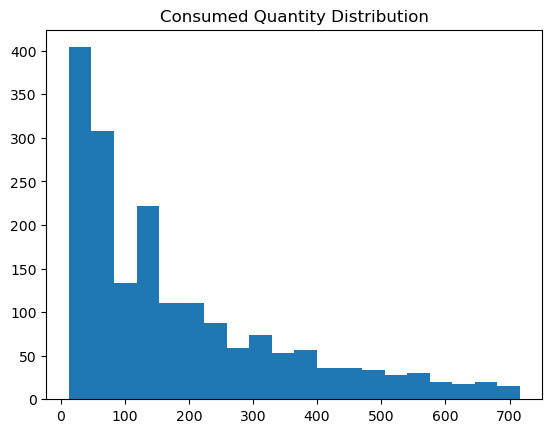

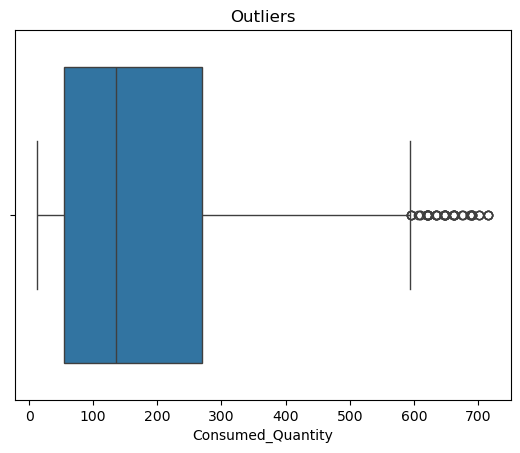

In [13]:
#visualization
plt.hist(dataset_encoded['Consumed_Quantity'],bins=20)
plt.title("Consumed Quantity Distribution")
plt.show()

sb.boxplot(x=dataset_encoded['Consumed_Quantity'])
plt.title("Outliers")
plt.show()

In [17]:
#the box plot with new outlier after removing extreme outlier

x=dataset[['Prepared_Quantity']]
y=dataset['Consumed_Quantity']
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2)  #20% data for testing and 80% data for training

model=LinearRegression()
model.fit(x_train,y_train)

dataset['Predicted_Consumption']=model.predict(dataset[['Prepared_Quantity']])
dataset['Predicted_Surplus']=dataset['Prepared_Quantity']-dataset['Predicted_Consumption']

print(dataset.head())

        Date Day_of_Week  Meal_Type  Prepared_Quantity  Consumed_Quantity  \
0 2015-01-15    Thursday  Breakfast              160.0              149.0   
1 2016-11-24    Thursday      Lunch              185.0              161.0   
2 2017-09-21    Thursday  Breakfast              168.0              149.0   
3 2015-10-08    Thursday      Lunch              555.0              540.0   
4 2015-11-05    Thursday      Lunch              283.0              271.0   

   Surplus    Waste_%  Consumed_Quantity_norm  Predicted_Consumption  \
0       11   6.875000                0.193457             143.495362   
1       24  12.972973                0.210526             168.317750   
2       19  11.309524                0.193457             151.438527   
3       15   2.702703                0.749644             535.689094   
4       12   4.240283                0.366999             265.621512   

   Predicted_Surplus  
0          16.504638  
1          16.682250  
2          16.561473  
3          1

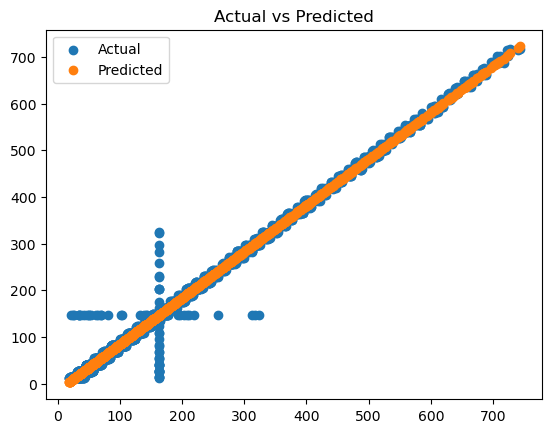

In [18]:
#prediction visualization
plt.scatter(dataset['Prepared_Quantity'],dataset['Consumed_Quantity'], label='Actual')
plt.scatter(dataset['Prepared_Quantity'],dataset['Predicted_Consumption'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [55]:
#future prediction
future_prepared=int(input("Enter quantity to prepare: "))
future_consumption=model.predict([[future_prepared]])[0]
future_surplus=future_prepared-future_consumption
future_waste=(future_surplus/future_prepared)*100

def decision(waste):
    if waste<0:
        return "Increase Preparation"
    elif waste>20:
        return "Reduce Preparation"
    elif waste>5:
        return "Optimal Preparation"
    else:
        return "Balanced"
print("Prepared: ",future_prepared)
print("Predicted Consumption: ",future_consumption)
print("Predicted Surplus: ",future_surplus)
print("Waste %: ",future_waste)
print("Decision: ",decision(future_waste))

Enter quantity to prepare:  200


Prepared:  200
Predicted Consumption:  183.21118334213284
Predicted Surplus:  16.78881665786716
Waste %:  8.39440832893358
Decision:  Optimal Preparation


C:\Users\Pratyaksh Tiwari\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
